In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

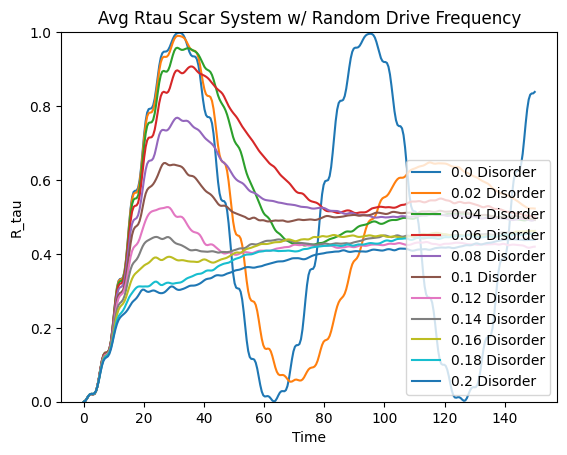

In [14]:
N = 6
dlist = np.linspace(0, 0.2, 11)
wd = 0.642570281124498
tlist = np.linspace(0, 150, 300)
args = {"A": 0.1}
Rtau_all = []

for d in dlist:
    Rtau = []
    for _ in range(25):
        dw = np.random.uniform(-d, d, N)
        omega_list = wd + dw

        H0, H1_list, eigenvalues, eigenstates, psi0, basisList = get_random_freq_scar_ham(N)
        H = [H0]

        for r in range(N):
            args[f"wd{r}"] = omega_list[r]
            H.append([H1_list[r], make_coeff(r)])

        H = qt.QobjEvo(H, args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau.append(np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])))
    Rtau = np.array(Rtau)
    Rtau = np.mean(Rtau, axis=0)
    Rtau_all.append(Rtau)

for i in range(len(Rtau_all)):
    plt.plot(tlist, Rtau_all[i], label=f"{dlist[i]} Disorder")

plt.title(f"Avg Rtau Scar System w/ Random Drive Frequency")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()